<a href="https://colab.research.google.com/github/nushuhu51-ux/TENSORFLOW-FULL-COURSE-FOR-DEEP-LEARNING/blob/main/01_neural_network_regression_with_tensorflow_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Regression with Neural Networks in TensorFlowiy.

There many definitions for a regression problems in our case, we're going to simplify:predicting a numerical variable based on some other combination of variable's, even shorter..predicting a number.

In [39]:
# import TensorFlow
import tensorflow as tf
print(tf.__version__)

2.20.0


### Creating data to view and fit

(<matplotlib.collections.PathCollection at 0x7ef481312b10>,)

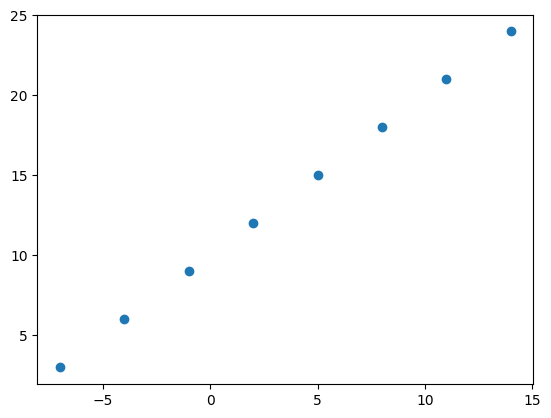

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# create features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0, ])

# create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# visualize
plt.scatter(x, y),

In [41]:
y == x+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and output shapes

In [42]:
# create a demo tensor for our housing price prediction problems
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])

house_info, house_price


(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [43]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

((), ())

In [44]:
x[0].ndim

0

In [45]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [46]:
# Turn our Numpy array into tensors
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
x, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [47]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

(TensorShape([]), TensorShape([]))

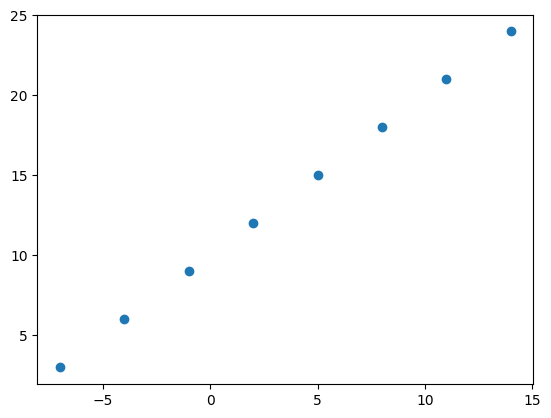

In [48]:
plt.scatter(x, y)

### steps in modelling with TensorFlow

1. Creating a model - define the input and output layer, as well as the hidden layers of a deep learing model.
2. Compiling a model - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer(tells our model how to improve the patterns its learning) and evaluation metrics(what we can use to interpret the performance of our model).
3. Fitting a model-letting the model try to find patterns between x & y (features and labels)

In [49]:
x = tf.reshape(x, (-1, 1))

In [50]:
# 1. Create a model (specified to your problem)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit the model
model.fit(x, y, epochs=5)

# 4. Evaluate the model
model.evaluate(x, y)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - loss: 9.8564 - mae: 9.8564
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.7239 - mae: 9.7239
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 9.5914 - mae: 9.5914
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 9.4589 - mae: 9.4589
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 9.3264 - mae: 9.3264
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 9.1939 - mae: 9.1939


[9.193949699401855, 9.193949699401855]

In [51]:
# check out x and y
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [52]:
# try and make a prediction using our model
y_pred = model.predict(tf.constant([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


array([[20.722244]], dtype=float32)

In [53]:
y_pred+11

array([[31.722244]], dtype=float32)

### Improving our model

we can improve our model, by altering the steps we took to create a model.

1. **Creating a model** - define the input and output layer, as well as the hidden layers of a deep learing model.
2. **Compiling a model** - here we night fit change the optimization function or perhaps the **learning rate** of the optimization function
3. **Fitting a model** - here we might fit a model for more (give the model more examples to learn from)

In [54]:
# let's rebuild our model

# 1. create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model.compile(loss=tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # sgd is short for stochasitc dradiant descent
              metrics=["mae"])
# 3. fit the model
model.fit(x, y, epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - loss: 16.3504 - mae: 16.3504
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 16.0692 - mae: 16.0692
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 15.7879 - mae: 15.7879
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 15.5067 - mae: 15.5067
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.2254 - mae: 15.2254
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.9442 - mae: 14.9442
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.7528 - mae: 14.7528
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 14.6203 - mae: 14.6203
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 14.4878 - mae: 14.4878
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 14.3553 - mae: 14.3553
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.2228 - mae: 14.2228
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 14.0903 - mae: 14.0903
Epoch 13/100
1/1 ━━━━━━━

In [55]:
# Remind ourselfs of the data
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [56]:
# Let's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


array([[29.699003]], dtype=float32)

In [57]:
# Let's see if we can make another to improve our model

# 1. create the model(this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss="mae",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step - loss: 14.1005 - mae: 14.1005
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 13.5796 - mae: 13.5796
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 13.0639 - mae: 13.0639
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 12.5495 - mae: 12.5495
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 12.0349 - mae: 12.0349
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 11.5166 - mae: 11.5166
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.9965 - mae: 10.9965
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 10.4573 - mae: 10.4573
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 9.9053 - mae: 9.9053
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 9.3336 - mae: 9.3336
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.7895 - mae: 8.7895
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 8.2026 - mae: 8.2026
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━

In [58]:
# let's remind ourselvs of the data
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [59]:
# let's try to make a prediction
model.predict(np.array([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


array([[32.824806]], dtype=float32)

### Evaluating a Model

In practice , a typical workflow you will go throgh when building neural networks is:

'''
Build a model -> fit it -> evaluate it -> tweak a model -> fit is -> evaluate is -> tweak a model -> ...

when it comes to evaluation... there are 3 words you should memorize:

> "Visualize, visualize, visualize"
 it is good to visualize:

 * The data- what data are we working with? what does it looks like?
 * the model itself-what does our model looks like?
 * the training of a model-how does a model perform while it learns?
 * the predictions of the model-how to the predictions of a model line up against of the ground truth?

In [60]:
# make a bigger dataset
x = tf.range(-100, 100, 4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [61]:
# make labels for the dataset
y = x+10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

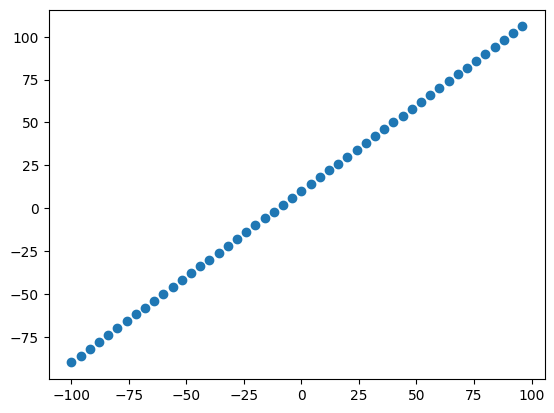

In [62]:
# visualize the data
import matplotlib.pyplot as plt
plt.scatter(x, y)

### The 3 sets...

* **training set**- the model learns from this data, which is typically 70-80% of the total data you have available.
* **validation set**- the model gets tuned on this data, which is typically 10-15% of the data available.
* **test set** - the model gets evaluated on this data to  test what is has learned, this set is typically 10-15% of the total data available.

In [63]:
# check the length of how many samples we have
len(x)

50

In [64]:
# split the data into train and test sets
x_train = x[:40]
y_train = y[:40]


x_test = x[40:]
y_test = y[40:]

len(x_train), len(x_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualizing the data

Now we've got our data in training and testing sets..let's as visualize is again!

(<matplotlib.legend.Legend at 0x7ef3334e1970>,)

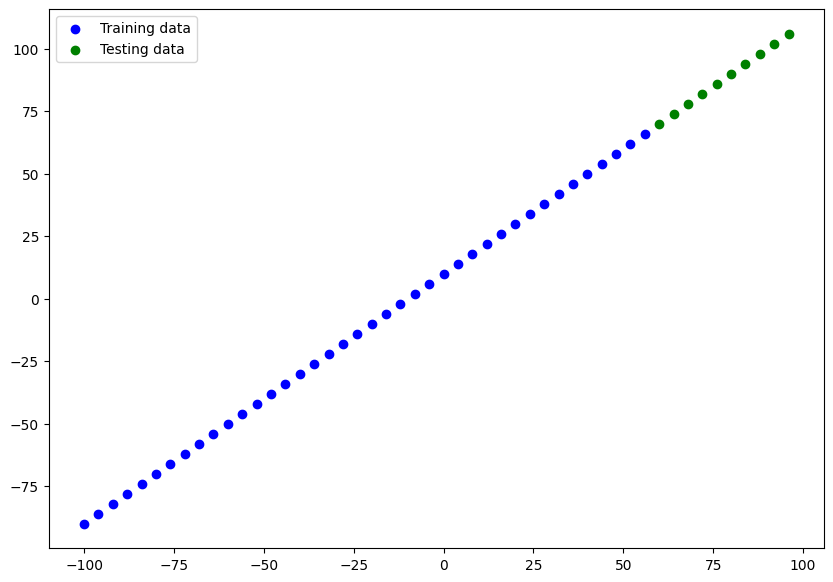

In [65]:
plt.figure(figsize=(10, 7))
# plot training the data in blue
plt.scatter(x_train, y_train, c="b", label="Training data")
# plot test data in green
plt.scatter(x_test, y_test, c="g", label="Testing data")
# show a legend
plt.legend(),

In [108]:
# Let's have a look at how to build a neural network for our data
tf.random.set_seed(42)
# 1. create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="Model_one")
# 2. compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. fit the model
model.fit(x_train, y_train, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 44.1422 - mae: 44.1422
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 32.7747 - mae: 32.7747
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 27.0262 - mae: 27.0262
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16.8560 - mae: 16.8560
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 18.6139 - mae: 18.6139
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 12.8366 - mae: 12.8366
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 18.0866 - mae: 18.0866
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14.0323 - mae: 14.0323
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 15.1040 - mae: 15.1040
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 15.8163 - mae: 15.8163
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 12.4723 - mae: 12.4723
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 15.0928 - mae: 15.0928 
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━

### Visualizing the model

In [109]:
model.summary()

Model: "Model_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

* Total params - total number of parameters in the model.
* Trainable params - these are the parameters the model can update as it trains.
* Non-trainable params- these parameters are not updated during training.

In [110]:
# Let's fit our model to the training data
model.fit(x_train, y_train, epochs=100, verbose=0)

In [111]:
# Get a summary of our model
model.summary()

Model: "Model_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

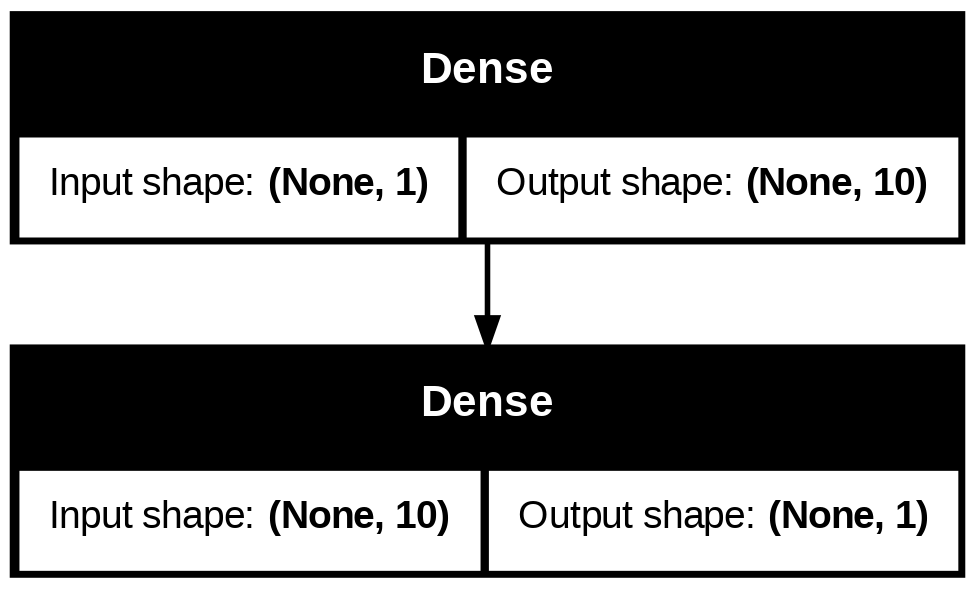

In [112]:
from tensorflow.keras.utils import plot_model
plot_model(model=model, show_shapes=True)

### Visualizing our model's predictions

T ovisualize predictions, it's a good idea to plot them against the ground truth labels.
offeten you'll see this in the form of y_test ot y_true versus y_pred

In [113]:
# make some predictions
y_preds = model.predict(x_test)
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


array([[45.476833],
       [48.304646],
       [51.132458],
       [53.960274],
       [56.78809 ],
       [59.615902],
       [62.443714],
       [65.27153 ],
       [68.09934 ],
       [70.92715 ]], dtype=float32)

In [138]:
print(x_test.shape)
print(y_pred.shape)

(10,)
(1, 1)


In [117]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [136]:
# let's create a plotting function
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=y_pred):
  """
  plots training data, test data and compares predictions to ground truth labels.
  """
  plt.figure(figsize=(10, 7))
  # plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # plot testing data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # plot model's predictions in red
  plt.scatter(test_data, predictions, c="r", label="predictions")
  # show the legend
  plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
(10,)
(10,)


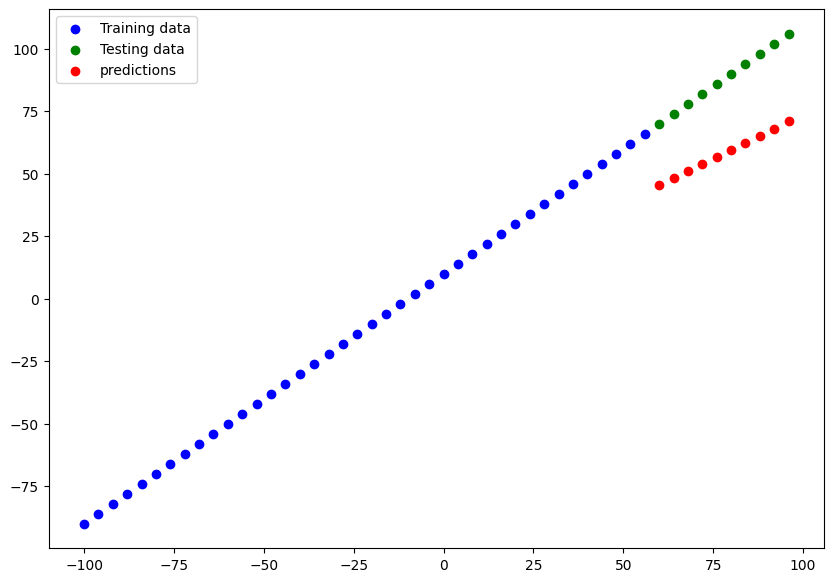

In [139]:
# Make predictions for ALL test data
y_pred = model.predict(x_test).squeeze()

# Check shapes
print(x_test.shape)
print(y_pred.shape)

# Plot
plot_predictions(
    train_data=x_train,
    train_labels=y_train,
    test_data=x_test,
    test_labels=y_test,
    predictions=y_pred
)

### Evaluating our model's predictions with regression evaluating metrics

Depending on the problem you are working on, there will be different evaluation metrics to evaluate your model's performance.
since we're working on a regression, two of the main metrics:
* MAE- Mean absolute error, "on average, how wrong is each of my model's predictions"
* MSE- mean squared error, "square the average errors"

In [142]:
# evaluate the model on the test set
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 29.7980 - mae: 29.7980


[29.798004150390625, 29.798004150390625]

In [156]:
# Create MAE object
mae = tf.keras.losses.MeanAbsoluteError()

# Calculate MAE
result = mae(y_test, y_pred)

# Print result
print(result.numpy())

29.798008


In [157]:
tf.constant(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([45.476833, 48.304646, 51.132458, 53.960274, 56.78809 , 59.615902,
       62.443714, 65.27153 , 68.09934 , 70.92715 ], dtype=float32)>

In [158]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [159]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([45.476833, 48.304646, 51.132458, 53.960274, 56.78809 , 59.615902,
       62.443714, 65.27153 , 68.09934 , 70.92715 ], dtype=float32)>

In [161]:
mae = tf.keras.losses.MeanAbsoluteError()(y_test, tf.squeeze(y_pred))

print(mae.numpy())

29.798008


In [ ]:
# calculate the mean square error
